# Bilfinger 2026 vehicle-level charging recordings

This notebook lists the files in the mediaTUM release, opens one CUPRA Born charging recording as released, and plots its pack voltage. It makes no diagnosis.

## 1. Released units

This step lists what `systems('bilfinger2026')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('bilfinger2026')
display(released)

,unit,kind,vehicle,format,member,bytes
0,Cupra_204_JB_8A_CEE7_C45,vehicle,Cupra 204,feather,DVA_robustness/data/Cupra/Cupra_204_JB_8A_CEE7...,11219114
1,Cupra_213_JB_8A_CEE7_C45,vehicle,Cupra 213,feather,DVA_robustness/data/Cupra/Cupra_213_JB_8A_CEE7...,10398410
2,Cupra_213_JB_8A_CEE7_C45_repeatability,vehicle,Cupra 213,feather,DVA_robustness/data/Cupra/Cupra_213_JB_8A_CEE7...,9276282
3,Cupra_213_JB_8A_CEE7_C45_repeatability_2,vehicle,Cupra 213,feather,DVA_robustness/data/Cupra/Cupra_213_JB_8A_CEE7...,3062762
4,Cupra_288_C10_discharge,vehicle,Cupra 288,feather,DVA_robustness/data/Cupra/Cupra_288_C10_discha...,5474034
5,Cupra_288_JB_10A_CEE16_C10,vehicle,Cupra 288,feather,DVA_robustness/data/Cupra/Cupra_288_JB_10A_CEE...,2694194
6,Cupra_288_JB_32A_CEE32_C6,vehicle,Cupra 288,feather,DVA_robustness/data/Cupra/Cupra_288_JB_32A_CEE...,774586
7,Cupra_288_JB_6A_CEE16_C17,vehicle,Cupra 288,feather,DVA_robustness/data/Cupra/Cupra_288_JB_6A_CEE1...,17741786
8,Cupra_288_JB_6A_CEE16_C17_outside,vehicle,Cupra 288,feather,DVA_robustness/data/Cupra/Cupra_288_JB_6A_CEE1...,4072738
9,Cupra_288_JB_8A_CEE7_C45,vehicle,Cupra 288,feather,DVA_robustness/data/Cupra/Cupra_288_JB_8A_CEE7...,3204794


Each row is one released file, with the vehicle it belongs to. Five CUPRA Born, one VW ID.3 and one Tesla Model 3 appear. The ID.3 and the Tesla are the two vehicles of bilfinger2024 and count once in the collection totals.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('bilfinger2026', unit='Cupra_204_JB_8A_CEE7_C45')
print(frame.shape)
display(frame.head())

(79591, 117)


name,cell_voltage_6,cell_voltage_1,cell_voltage_66,cell_voltage_51,cell_voltage_102,cell_voltage_87,cell_voltage_62,cell_voltage_107,cell_voltage_95,cell_voltage_26,...,cell_voltage_12,cell_voltage_84,cell_voltage_83,cell_voltage_41,time_ms,time_s,time_min,time_h,date,Q
0,3.325,3.329,3.320,3.317,3.318,3.315,3.291,3.322,3.332,3.303,...,3.319,3.325,3.317,3.317,0.000000,0.000000,0.000000,0.000000,2022-11-16 17:34:23.107848192,0.000000
1,3.326,3.329,3.321,3.318,3.320,3.320,3.293,3.323,3.333,3.308,...,3.320,3.325,3.322,3.318,2010.128128,2.010128,0.033502,0.000558,2022-11-16 17:34:25.117976320,0.001912
2,3.326,3.330,3.322,3.319,3.320,3.321,3.293,3.324,3.333,3.309,...,3.320,3.326,3.323,3.318,4025.221120,4.025221,0.067087,0.001118,2022-11-16 17:34:27.133069312,0.004249
3,3.326,3.330,3.322,3.318,3.320,3.320,3.295,3.324,3.334,3.309,...,3.320,3.326,3.324,3.319,6034.792448,6.034792,0.100580,0.001676,2022-11-16 17:34:29.142640640,0.006597
4,3.327,3.330,3.322,3.318,3.321,3.320,3.295,3.324,3.334,3.309,...,3.320,3.327,3.324,3.319,8044.527616,8.044528,0.134075,0.002235,2022-11-16 17:34:31.152375808,0.009025


The recording is one charge of CUPRA 204. Column order differs between files in this release, so columns are selected by name.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['U', 'I', 'SOC', 'Q', 'cell_voltage_1']].describe().T)

,count,mean,std,min,25%,50%,75%,max
name,,,,,,,,
U,79591.0,407.225811,23.973022,358.250,389.500000,401.250000,427.250000,454.00000
I,79591.0,3.385897,0.248288,2.020,3.190000,3.410000,3.580000,4.52000
SOC,79591.0,49.430383,27.815456,0.000,25.600000,50.000000,73.600000,96.00000
Q,79591.0,78.344097,43.620646,0.000,40.810799,79.734766,116.529439,151.01601
cell_voltage_1,79591.0,3.773619,0.221971,3.329,3.609000,3.718000,3.960000,4.20800


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

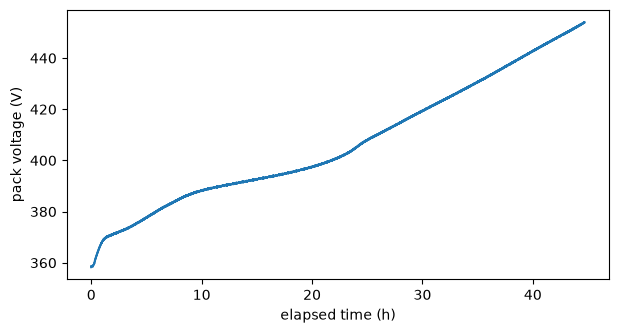

In [4]:
ax = frame.plot(x='time_h', y='U', legend=False, figsize=(7, 3.5))
ax.set_xlabel('elapsed time (h)')
ax.set_ylabel('pack voltage (V)')
plt.show()

Pack voltage rises through the charge, the shape the paper's differential voltage analysis starts from.